<a href="https://colab.research.google.com/github/Piyush-Sharma-1/Diffusion_from_Scratch/blob/main/Vae_on_CelebA_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SoC Diffusion — Week 5: Face VAE at Scale
Run this notebook top-to-bottom on a **Colab T4 GPU** (Runtime → Change runtime type → T4 GPU).

It covers all 4 assignment parts:
- Part 1: Train FaceVAE on CelebA (20 epochs) + loss plots
- Part 2: Reconstructions, generated faces, interpolation
- Part 3: Beta experiment (β=0.3 vs β=1.0)
- Part 4: Reflection


## Step 0 — Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type != "cuda":
    print("WARNING: This week needs a GPU! Go to Runtime > Change runtime type > T4 GPU")


Using device: cuda


## Mount Google Drive
Uncomment to save checkpoints/models where they survive a runtime disconnect.

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# save_root = "/content/drive/MyDrive/soc_diffusion/week5"
save_root = "."
os.makedirs(save_root, exist_ok=True)


## Step 1 — Load CelebA

In [12]:
# ===== Step 1 : Load CelebA via Kaggle =====
!pip install -q kaggle

import os, json

KAGGLE_USERNAME = "YOUR_KAGGLE_USERNAME"
KAGGLE_KEY = "PASTE_YOUR_COPIED_KEY_HERE"

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Skip re-downloading if already present
if not os.path.exists("./data/img_align_celeba"):
    os.system("kaggle datasets download -d jessicali9530/celeba-dataset -p ./data --unzip")

import glob
all_jpgs = sorted(glob.glob("./data/**/*.jpg", recursive=True))
print(f"Found {len(all_jpgs)} jpg files")

if len(all_jpgs) == 0:
    raise RuntimeError("No jpgs found under ./data — download/unzip failed.")

from PIL import Image
from torch.utils.data import Dataset

class CelebAFolder(Dataset):
    def __init__(self, paths, transform=None, limit=None):
        self.paths = paths[:limit] if limit is not None else paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

image_size = 64

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

dataset = CelebAFolder(all_jpgs, transform=transform, limit=50000)
print(f"Dataset size: {len(dataset)}")

batch_size = 64
train_loader = DataLoader(
    dataset, batch_size=batch_size, shuffle=True,
    num_workers=2, pin_memory=True
)

val_size = 2000
full_len = len(dataset)
val_dataset = Subset(dataset, range(full_len - val_size, full_len))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

images, _ = next(iter(train_loader))
print(f"Batch shape: {images.shape}")
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")
print(f"Training samples: {len(dataset):,}")

Found 202599 jpg files
Dataset size: 50000
Batch shape: torch.Size([64, 3, 64, 64])
Pixel range: [0.00, 1.00]
Training samples: 50,000


## Step 2 — Scaled-Up Conv VAE

In [13]:
class FaceVAE(nn.Module):
    def __init__(self, latent_dim=128, hidden_dims=None, kernel_size=3):
        super().__init__()
        self.latent_dim = latent_dim
        if hidden_dims is None:
            hidden_dims = [64, 128, 256, 512]

        encoder_layers = []
        in_ch = 3
        for out_ch in hidden_dims:
            encoder_layers.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, stride=2, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
            ])
            in_ch = out_ch
        encoder_layers.append(nn.Flatten())
        self.encoder = nn.Sequential(*encoder_layers)

        n_layers = len(hidden_dims)
        spatial_size = 64 // (2 ** n_layers)
        self.flattened_size = hidden_dims[-1] * (spatial_size ** 2)

        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, self.flattened_size)

        decoder_layers = []
        rev_dims = list(reversed(hidden_dims))
        for i in range(len(rev_dims) - 1):
            decoder_layers.extend([
                nn.ConvTranspose2d(rev_dims[i], rev_dims[i+1],
                                   kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(rev_dims[i+1]),
                nn.ReLU(),
            ])
        decoder_layers.extend([
            nn.ConvTranspose2d(rev_dims[-1], 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        ])
        self.decoder = nn.Sequential(*decoder_layers)

        self.last_channel = hidden_dims[-1]
        self.spatial_size = spatial_size

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.last_channel, self.spatial_size, self.spatial_size)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


## Step 3 — Loss Function

In [14]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


## Step 4 — Training Loop

In [15]:
def train_epoch(model, loader, optimizer, beta=1.0):
    model.train()
    total_loss, total_recon, total_kl = 0, 0, 0
    pbar = tqdm(loader, desc="Training", leave=False)
    for x, _ in pbar:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon_l.item()
        total_kl += kl_l.item()
        pbar.set_postfix({'loss': f'{loss.item()/len(x):.1f}'})
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


@torch.no_grad()
def evaluate(model, loader, beta=1.0):
    model.eval()
    total_loss, total_recon, total_kl = 0, 0, 0
    for x, _ in tqdm(loader, desc="Evaluating", leave=False):
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar, beta=beta)
        total_loss += loss.item()
        total_recon += recon_l.item()
        total_kl += kl_l.item()
    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


def run_training(latent_dim, beta, epochs, lr=1e-3, tag="model"):
    model = FaceVAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{tag}] parameters: {n_params:,} | beta={beta} | epochs={epochs}")

    history = {"train_loss": [], "train_recon": [], "train_kl": [],
               "val_loss": [], "val_recon": [], "val_kl": []}

    print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Recon':>12} {'Train KL':>12} "
          f"{'Val Loss':>12} {'Val Recon':>12} {'Val KL':>12}")
    print("-" * 78)

    for epoch in range(1, epochs + 1):
        train_l, train_r, train_k = train_epoch(model, train_loader, optimizer, beta=beta)
        val_l, val_r, val_k = evaluate(model, val_loader, beta=beta)
        for d, v in [("train_loss", train_l), ("train_recon", train_r), ("train_kl", train_k),
                     ("val_loss", val_l), ("val_recon", val_r), ("val_kl", val_k)]:
            history[d].append(v)
        print(f"{epoch:>6} {train_l:>12.2f} {train_r:>12.2f} {train_k:>12.2f} "
              f"{val_l:>12.2f} {val_r:>12.2f} {val_k:>12.2f}")

        if epoch % 5 == 0:
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'history': history},
                       f"{save_root}/{tag}_checkpoint_epoch_{epoch}.pt")

    torch.save(model.state_dict(), f"{save_root}/{tag}_final.pt")
    return model, history


## Part 1 — Train the Main Model with Beta=0.5


In [16]:
LATENT_DIM = 128
LEARNING_RATE = 1e-3
EPOCHS = 20
BETA = 0.5

model, history = run_training(LATENT_DIM, BETA, EPOCHS, LEARNING_RATE, tag="main")
print("\nTraining complete. Model saved to", f"{save_root}/main_final.pt")


[main] parameters: 7,464,003 | beta=0.5 | epochs=20
 Epoch   Train Loss  Train Recon     Train KL     Val Loss    Val Recon       Val KL
------------------------------------------------------------------------------


     1       296.69       240.93       111.52       221.78       170.38       102.79


     2       192.42       144.08        96.69       182.76       133.87        97.78


     3       175.64       127.23        96.82       183.53       132.88       101.28


     4       168.40       119.62        97.57       166.95       118.08        97.74


...

    16       147.14        96.10       102.09       148.15        95.93       104.43


    17       146.19        95.09       102.19       146.75        96.12       101.27


    18       145.55        94.45       102.21       144.33        92.85       102.94


    19       144.96        93.83       102.26       143.50        92.10       102.80


    20       144.37        93.19       102.35       142.36        91.83       101.07

Training complete. Model saved to ./main_final.pt


### Plot reconstruction loss and KL loss separately (Part 1 requirement)

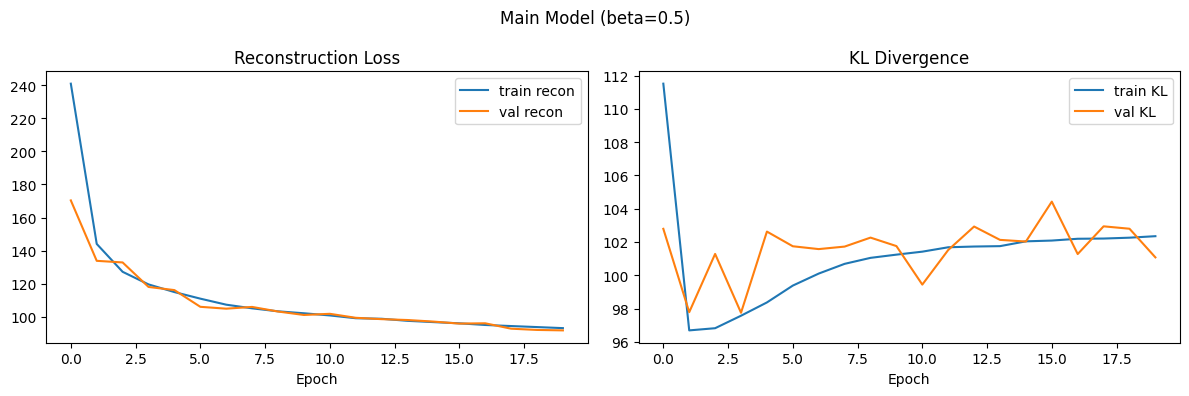

In [17]:
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_recon"], label="train recon")
    axes[0].plot(history["val_recon"], label="val recon")
    axes[0].set_title("Reconstruction Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history["train_kl"], label="train KL")
    axes[1].plot(history["val_kl"], label="val KL")
    axes[1].set_title("KL Divergence")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history, "Main Model (beta=0.5)")


## Part 2 — Visualizations

### 1. Face Reconstructions

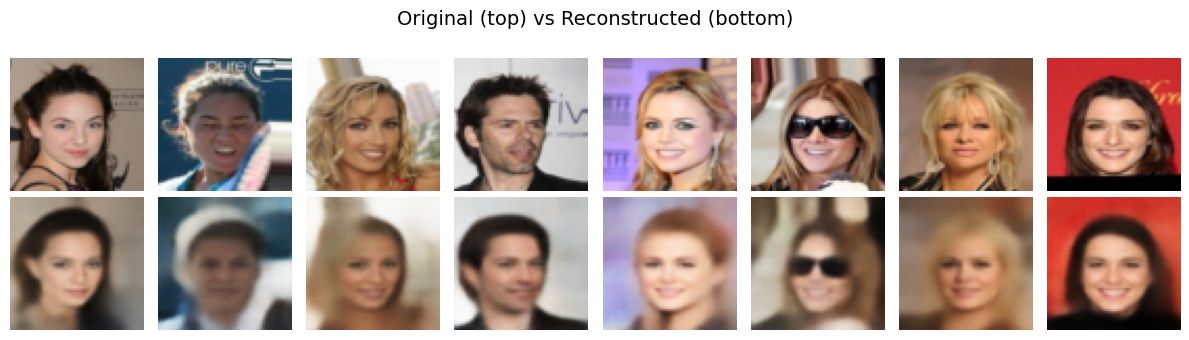

In [18]:
@torch.no_grad()
def show_face_reconstructions(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    recon, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(n*1.5, 3.5))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0).cpu())
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].permute(1, 2, 0).cpu())
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel("Original", fontsize=12)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

show_face_reconstructions(model, val_loader, n=8)


### 2. Generated Faces (sampled from the prior)

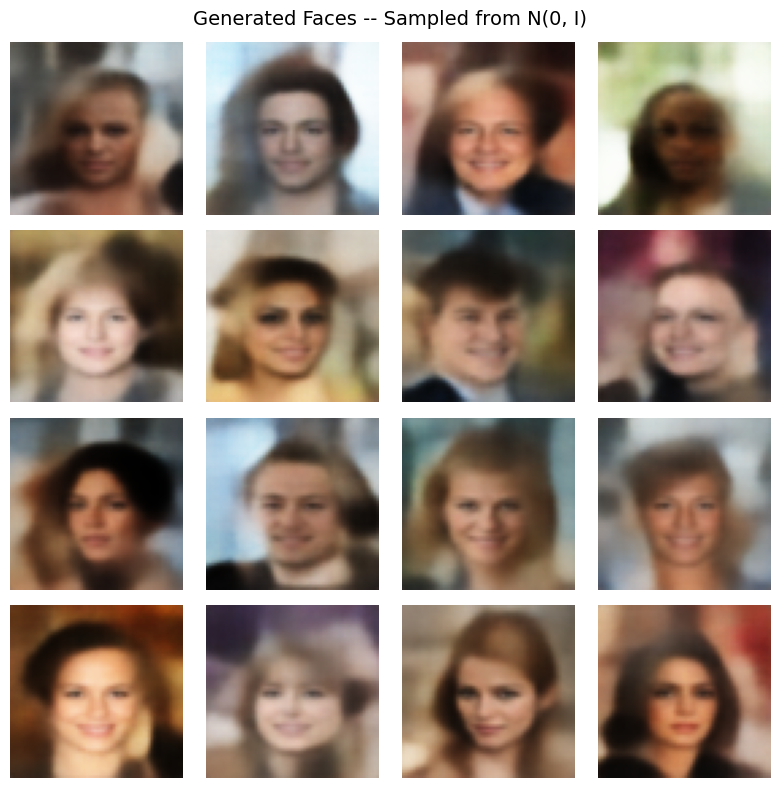

In [19]:
@torch.no_grad()
def generate_faces(model, n=16, latent_dim=128):
    model.eval()
    z = torch.randn(n, latent_dim).to(device)
    samples = model.decode(z)
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].permute(1, 2, 0).cpu())
        ax.axis('off')
    plt.suptitle("Generated Faces -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_faces(model, n=16, latent_dim=LATENT_DIM)


### 3. Latent Space Interpolation Check

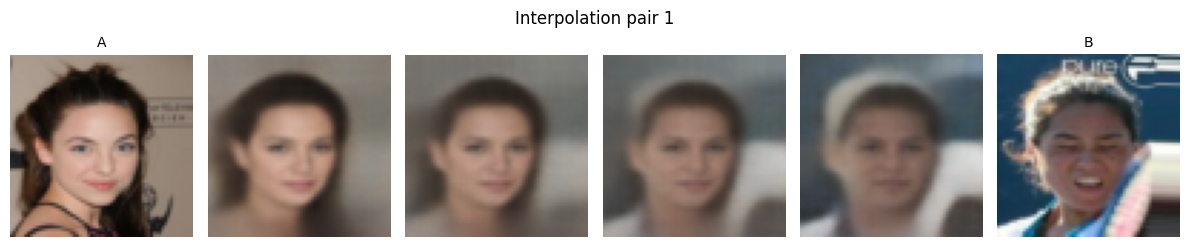

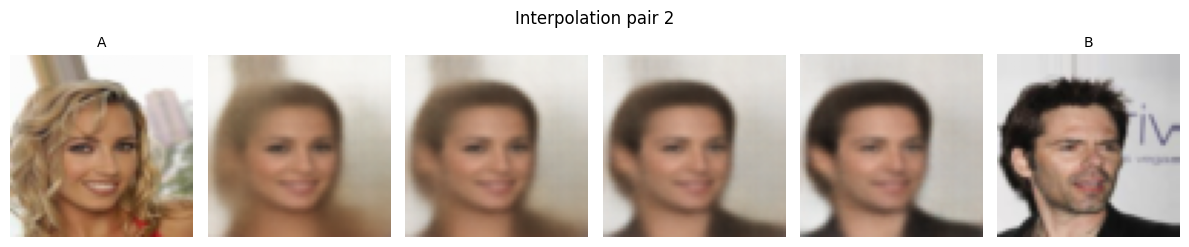

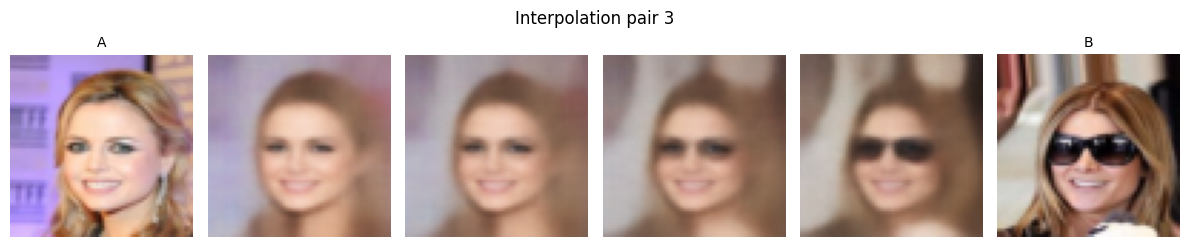

In [20]:
@torch.no_grad()
def latent_quality_check(model, loader, n_pairs=3):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    for pair in range(n_pairs):
        img1 = x[pair*2:pair*2+1]
        img2 = x[pair*2+1:pair*2+2]
        mu1, _ = model.encode(img1)
        mu2, _ = model.encode(img2)

        fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
        axes[0].imshow(img1[0].permute(1,2,0).cpu())
        axes[0].set_title("A", fontsize=10); axes[0].axis('off')

        for i, alpha in enumerate([0.2, 0.4, 0.6, 0.8]):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            recon = model.decode(z_interp)
            axes[i+1].imshow(recon[0].permute(1,2,0).cpu())
            axes[i+1].axis('off')

        axes[5].imshow(img2[0].permute(1,2,0).cpu())
        axes[5].set_title("B", fontsize=10); axes[5].axis('off')
        plt.suptitle(f"Interpolation pair {pair+1}", fontsize=12)
        plt.tight_layout()
        plt.show()

latent_quality_check(model, val_loader, n_pairs=3)


## Part 3 — Beta Experiment
Train two more models with β=0.3 and β=1.0 (fewer epochs to keep this quick — bump `BETA_EPOCHS` up if you have time).

In [22]:
BETA_EPOCHS = 20

model_b03, hist_b03 = run_training(LATENT_DIM, 0.3, BETA_EPOCHS, LEARNING_RATE, tag="beta_0.3")
model_b10, hist_b10 = run_training(LATENT_DIM, 1.0, BETA_EPOCHS, LEARNING_RATE, tag="beta_1.0")


[beta_0.3] parameters: 7,464,003 | beta=0.3 | epochs=20
 Epoch   Train Loss  Train Recon     Train KL     Val Loss    Val Recon       Val KL
------------------------------------------------------------------------------


     1       260.21       220.23       133.28       176.15       138.49       125.55


     2       163.40       125.29       127.05       150.80       112.63       127.22


     3       148.53       110.00       128.45       146.39       106.28       133.72


     4       141.74       102.74       130.01       140.59       100.59       133.33


...

    16       189.06       123.63        65.42       191.70       125.06        66.64


    17       188.60       123.15        65.45       187.01       121.92        65.09


    18       187.96       122.45        65.52       186.17       120.49        65.69


    19       187.47       121.90        65.56       186.44       122.02        64.41


    20       187.04       121.47        65.57       185.32       120.22        65.10


### Side-by-side reconstruction comparison across beta values

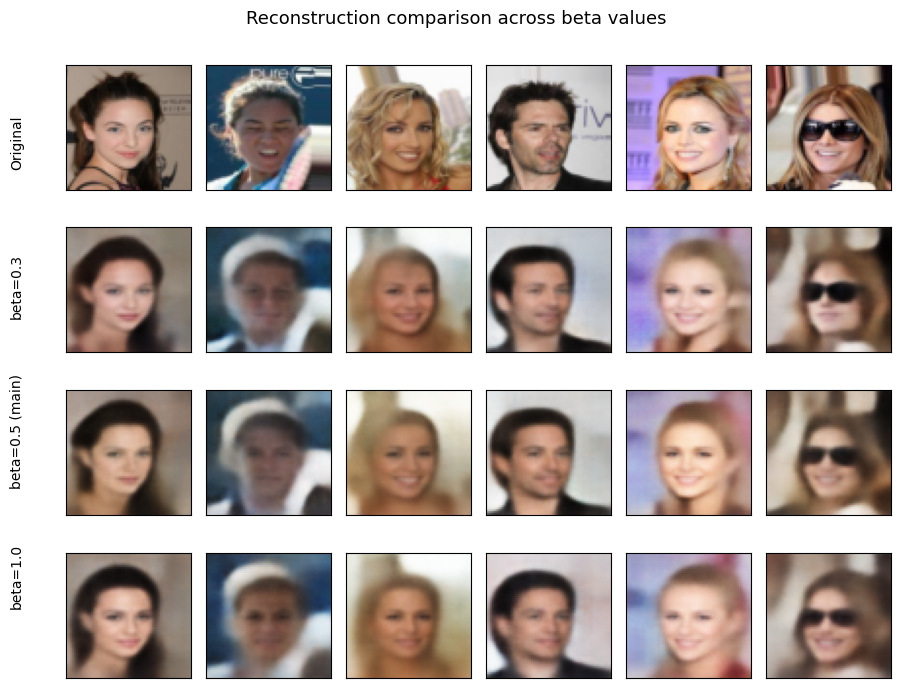

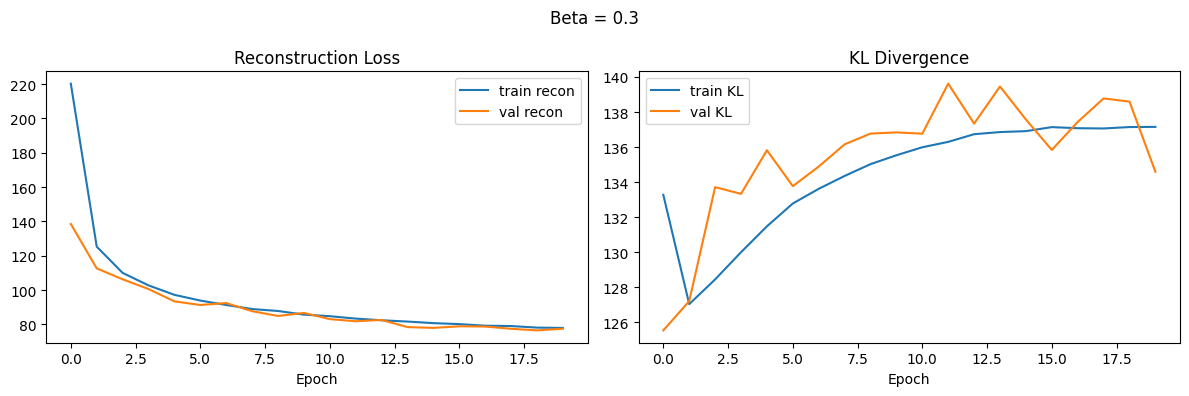

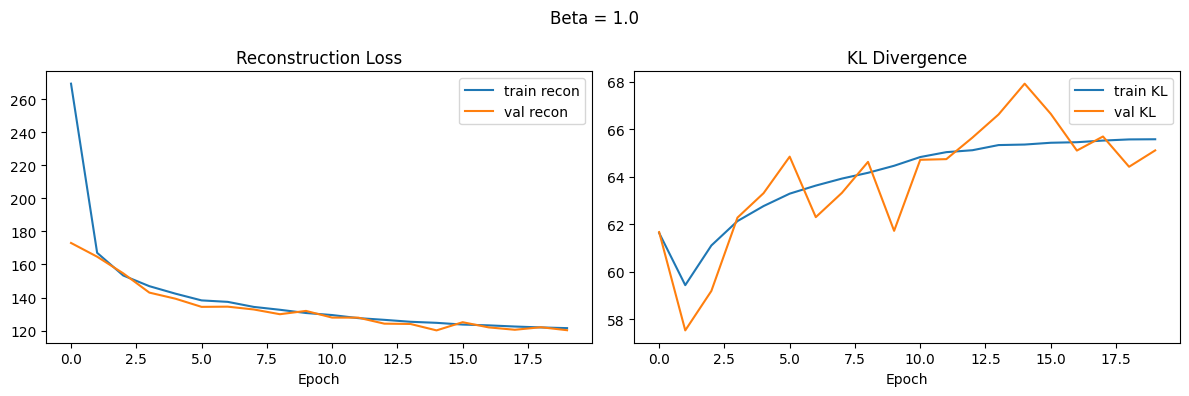

In [24]:
@torch.no_grad()
def compare_betas(models_dict, loader, n=6):
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    rows = 1 + len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(n*1.5, rows*1.8))

    row_labels = ["Original"] + list(models_dict.keys())

    for i in range(n):
        axes[0, i].imshow(x[i].permute(1,2,0).cpu())
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])

    for row, (label, m) in enumerate(models_dict.items(), start=1):
        m.eval()
        recon, _, _ = m(x)
        for i in range(n):
            axes[row, i].imshow(recon[i].permute(1,2,0).cpu())
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])

    # Add row labels on the left using fig.text (more reliable than set_ylabel + axis('off'))
    for row in range(rows):
        pos = axes[row, 0].get_position()
        fig.text(0.02, (pos.y0 + pos.y1) / 2, row_labels[row],
                  va='center', ha='right', fontsize=10, rotation=90)

    plt.suptitle("Reconstruction comparison across beta values", fontsize=13)
    plt.tight_layout(rect=[0.05, 0, 1, 1])  # leave room on the left for labels
    plt.show()

compare_betas({"beta=0.3": model_b03, "beta=0.5 (main)": model, "beta=1.0": model_b10}, val_loader, n=6)
plot_history(hist_b03, "Beta = 0.3")
plot_history(hist_b10, "Beta = 1.0")

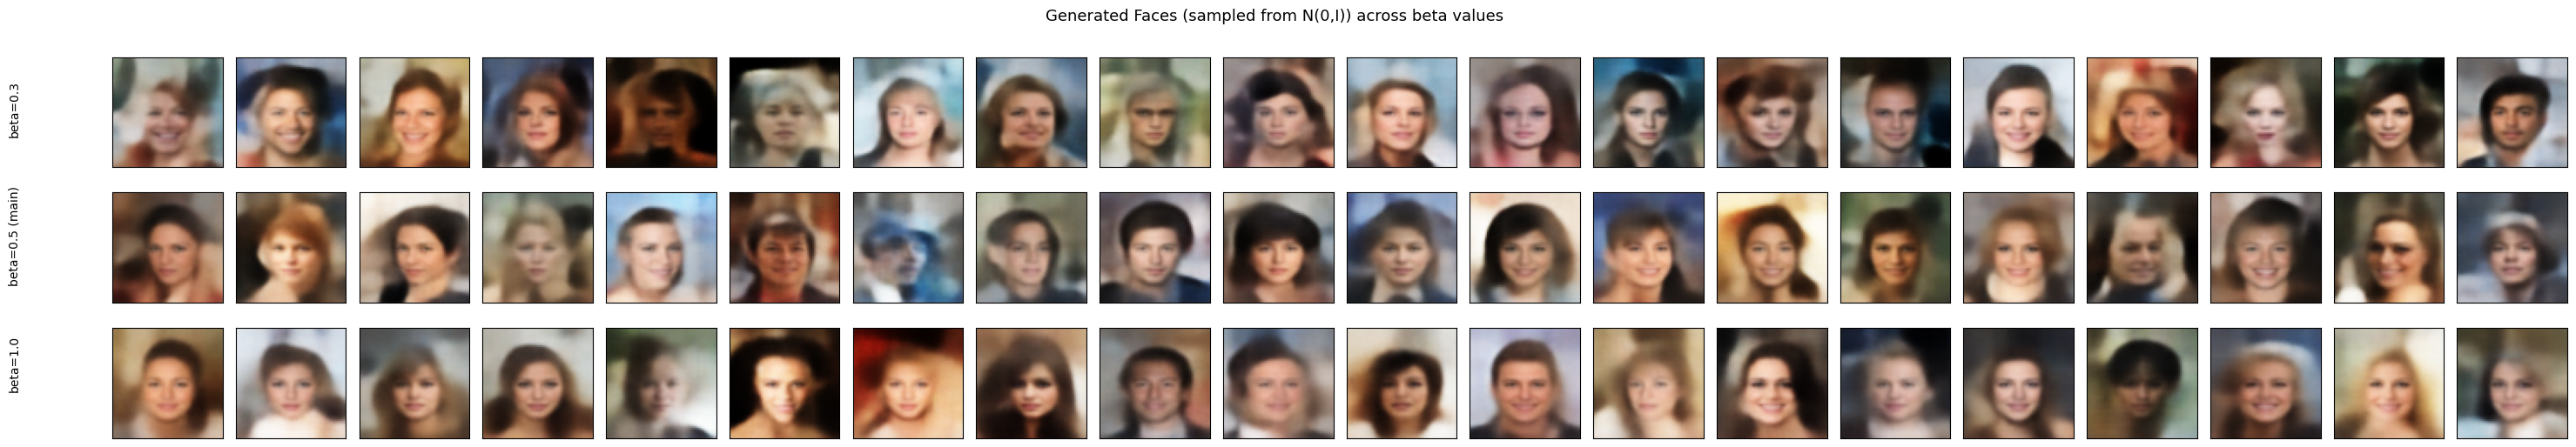

In [26]:
@torch.no_grad()
def compare_beta_generations(models_dict, n=6, latent_dim=128, seed=42):
    torch.manual_seed(seed)  # same z's across models for a fair comparison
    rows = len(models_dict)
    fig, axes = plt.subplots(rows, n, figsize=(n*1.5, rows*1.8))

    row_labels = list(models_dict.keys())

    for row, (label, m) in enumerate(models_dict.items()):
        m.eval()
        torch.manual_seed(seed)  # reset so every model sees the same random z's
        z = torch.randn(n, latent_dim).to(device)
        samples = m.decode(z)
        for i in range(n):
            axes[row, i].imshow(samples[i].permute(1,2,0).cpu())
            axes[row, i].set_xticks([])
            axes[row, i].set_yticks([])

    for row in range(rows):
        pos = axes[row, 0].get_position()
        fig.text(0.02, (pos.y0 + pos.y1) / 2, row_labels[row],
                  va='center', ha='right', fontsize=10, rotation=90)

    plt.suptitle("Generated Faces (sampled from N(0,I)) across beta values", fontsize=13)
    plt.tight_layout(rect=[0.05, 0, 1, 1])
    plt.show()

compare_beta_generations(
    {"beta=0.3": model_b03, "beta=0.5 (main)": model, "beta=1.0": model_b10},
    n=20, latent_dim=LATENT_DIM
)

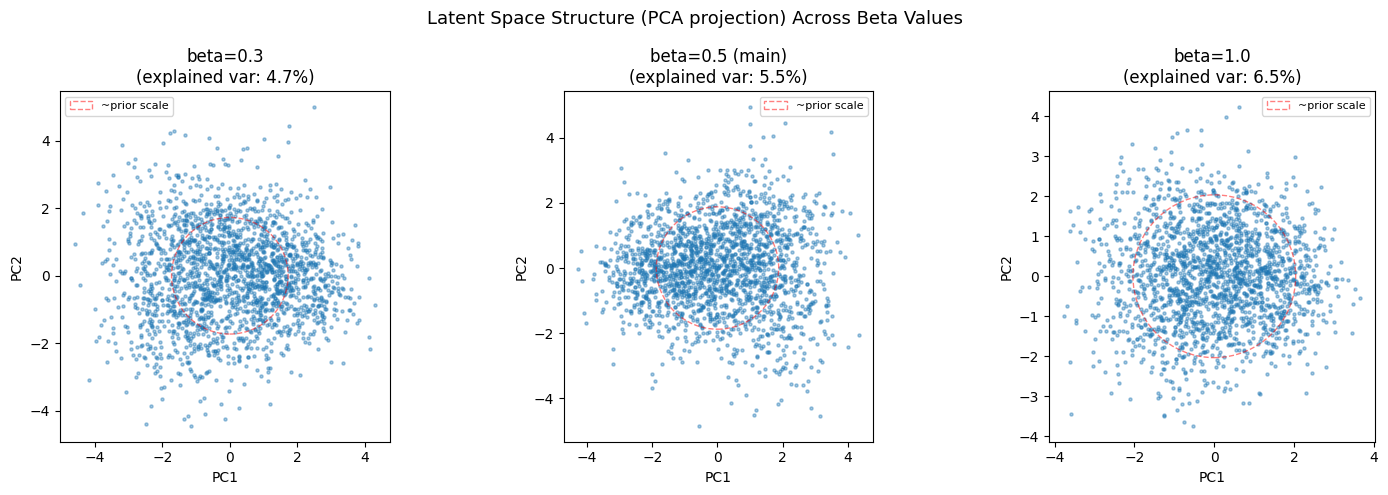

In [27]:
from sklearn.decomposition import PCA

@torch.no_grad()
def get_latents(model, loader, max_samples=2000):
    model.eval()
    all_mu = []
    count = 0
    for x, _ in loader:
        x = x.to(device)
        mu, _ = model.encode(x)
        all_mu.append(mu.cpu())
        count += x.size(0)
        if count >= max_samples:
            break
    return torch.cat(all_mu, dim=0)[:max_samples].numpy()

def compare_latent_spaces(models_dict, loader, max_samples=2000):
    fig, axes = plt.subplots(1, len(models_dict), figsize=(5*len(models_dict), 5))
    if len(models_dict) == 1:
        axes = [axes]

    for ax, (label, m) in zip(axes, models_dict.items()):
        latents = get_latents(m, loader, max_samples=max_samples)

        # Project to 2D with PCA
        pca = PCA(n_components=2)
        z_2d = pca.fit_transform(latents)

        ax.scatter(z_2d[:, 0], z_2d[:, 1], s=5, alpha=0.4)
        ax.set_title(f"{label}\n(explained var: {pca.explained_variance_ratio_.sum():.1%})")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

        # Reference: what a standard normal prior would look like in the same PCA space
        # (helps show how far the encoder's latents drift from N(0,I))
        radius = np.sqrt(latents.shape[1])  # expected norm of a standard normal in latent_dim dims
        circle = plt.Circle((0, 0), radius * pca.explained_variance_ratio_[:2].mean()**0.5,
                             fill=False, linestyle='--', color='red', alpha=0.5, label='~prior scale')
        ax.add_patch(circle)
        ax.legend(fontsize=8)
        ax.set_aspect('equal')

    plt.suptitle("Latent Space Structure (PCA projection) Across Beta Values", fontsize=13)
    plt.tight_layout()
    plt.show()

compare_latent_spaces(
    {"beta=0.3": model_b03, "beta=0.5 (main)": model, "beta=1.0": model_b10},
    val_loader, max_samples=2000
)

In [28]:
from google.colab import files
files.download("main_final.pt")  # or "model.pt" if you renamed it

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Questions:**

*Which β produces better faces? Which produces a smoother latent space? Why does this trade-off exist?*

> Lower β (e.g. 0.3) weakens the KL penalty, so the encoder is freer to place faces wherever helps reconstruction most — reconstructions look sharper, but the latent space is less regularized (less smooth/continuous), so samples drawn from N(0, I) or interpolations can look worse. Higher β (e.g. 1.0) forces the posterior closer to the prior, giving a smoother, more sample-able latent space at the cost of blurrier reconstructions. This is the classic VAE rate-distortion trade-off between reconstruction fidelity and latent regularity.


## Part 4 — Reflection

**What was the biggest difference between training on MNIST (Week 4) and CelebA (Week 5)? What would you do differently if you had an A100 GPU?**

Training went from minutes on CPU to hours on GPU, RGB/64x64 images and a 4-layer/512-channel architecture needed far more memory and compute than 1-channel 28x28 digits, and batch size / checkpointing became real engineering concerns rather than afterthoughts. With an A100, I would use the full 162,770-image training set instead of a subset, increase batch_size to 128+, train for the full 30+ epochs, and try latent_dim=256 or image_size=128 for sharper faces.